# Homework 4

## Problem 3

### (a) Correlation between Climate Indices

**Calculate correlations among Nino 3.4, PDO, AMM, AMO, Hurricane Number, plus another two indices of your choice.**

Update: Some indices at NOAA/PSL website are out of maintenance. You can access hurricane number here: https://tropical.atmos.colostate.edu/Realtime/index.php?arch&loc=northatlantic 

In [ ]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Next we compute the correlation matrix

In [3]:
hurricane = pd.read_csv("data/hurricane_number.csv", header=0, index_col=0,  sep='\\s+', engine='python')
hurricane_num = hurricane["Hurricanes"]
amm = (pd.read_csv("data/amm.csv", header=0, index_col=0,  sep='\\s+', engine='python')).mean(axis=1)
amo = (pd.read_csv("data/amo.csv", header=0, index_col=0,  sep='\\s+', engine='python')).mean(axis=1)
pdo = (pd.read_csv("data/pdo.csv", header=0, index_col=0,  sep='\\s+', engine='python')).mean(axis=1)
ao =  (pd.read_csv("data/ao.csv", header=0, index_col=0,  sep='\\s+', engine='python')).mean(axis=1)
enso_precip = (pd.read_csv("data/enso_precp.csv", header=0, index_col=0,  sep='\\s+', engine='python')).mean(axis=1)
nino = (pd.read_csv("data/nino3.4.csv", header=0, index_col=0,  sep='\\s+', engine='python')).mean(axis=1)
correlation = pd.DataFrame({"amm" : amm, "amo" : amo, "pdo" : pdo, "hurricane_num" : hurricane_num, "ao" : ao, "enso precipitatoin": enso_precip, "nino 3.4": nino}).dropna().corr()
print(correlation)

                         amm       amo       pdo  hurricane_num        ao  \
amm                 1.000000 -0.189768  0.288536      -0.005008  0.004650   
amo                -0.189768  1.000000 -0.272004       0.569140 -0.355524   
pdo                 0.288536 -0.272004  1.000000      -0.294670 -0.171069   
hurricane_num      -0.005008  0.569140 -0.294670       1.000000 -0.182270   
ao                  0.004650 -0.355524 -0.171069      -0.182270  1.000000   
enso precipitatoin  0.999418 -0.205527  0.308380      -0.026758  0.009275   
nino 3.4           -0.211950 -0.168143  0.498296      -0.425547  0.064576   

                    enso precipitatoin  nino 3.4  
amm                           0.999418 -0.211950  
amo                          -0.205527 -0.168143  
pdo                           0.308380  0.498296  
hurricane_num                -0.026758 -0.425547  
ao                            0.009275  0.064576  
enso precipitatoin            1.000000 -0.183894  
nino 3.4                  

We can visualize the result better using a heat map

Text(0.5, 1.0, 'Pearson Correlation Matrix Between Climate Indices')

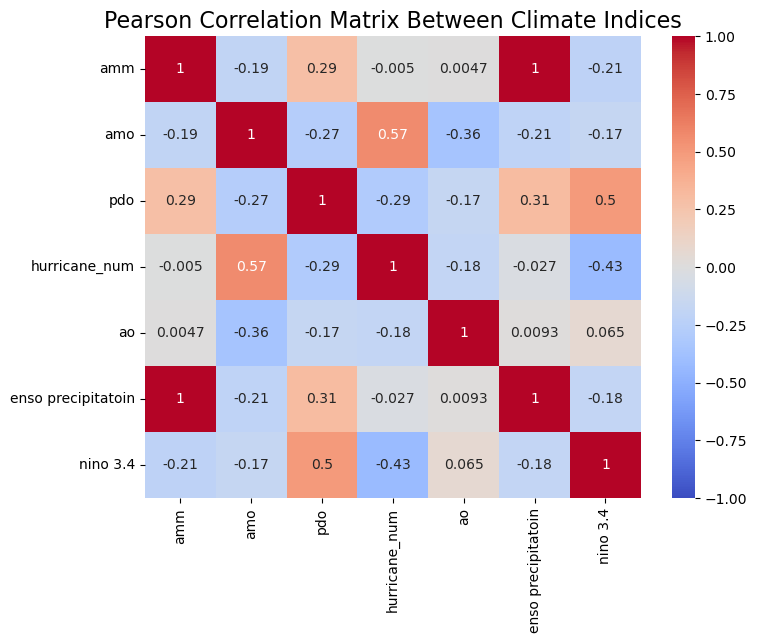

In [4]:
plt.figure(figsize=(8, 6)) # Adjust figure size as needed
sns.heatmap(correlation, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Pearson Correlation Matrix Between Climate Indices", fontsize=16, loc='center')

### (b) Climate Composite 

**Work with one index and rank its values. Identify the years with most positive and most negative values. Plot climate composites using precipitation data**


:::{tip}
I'll choose **amm** as my index.
:::

Year
2023   -91.641500
1974    -0.447500
1976    -0.391667
1972    -0.379250
1971    -0.336833
          ...    
1952     0.278583
2017     0.280417
2016     0.307500
2010     0.315083
1998     0.339667
Length: 76, dtype: float64

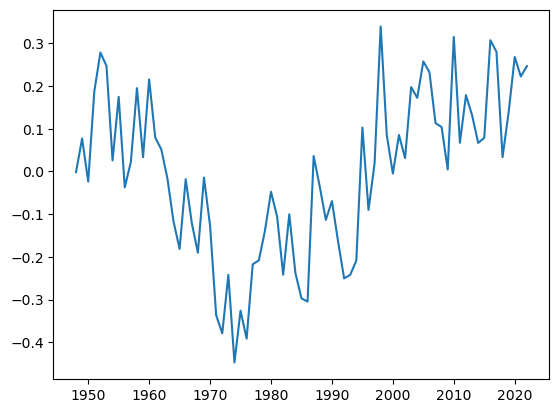

In [29]:
fig, ax = plt.subplots() 
ax.plot(amm.index[0:len(amm)-1], amm.to_numpy()[0:len(amm)-1])
amm.sort_values()


Let's download the precipitation data that correspond to the lowest/highest *amm index* years.

In [30]:
import cdsapi

dataset = "reanalysis-era5-single-levels-monthly-means"
request = {
    "product_type": ["monthly_averaged_reanalysis"],
    "variable": ["total_precipitation"],
    "year": [
        "1998", "2010", "2016", 
        "1974", "1976", "1972" 
    ],
    "month": [
        "01", "02", "03",
        "04", "05", "06",
        "07", "08", "09",
        "10", "11", "12"
    ],
    "time": ["00:00"],
    "data_format": "grib",
    "download_format": "unarchived"
}

client = cdsapi.Client()
client.retrieve(dataset, request).download()


2026-03-13 01:19:02,719 INFO Request ID is 1454da9c-cd4c-4676-997d-27adcf7a9418
2026-03-13 01:19:02,884 INFO status has been updated to accepted
2026-03-13 01:19:17,044 INFO status has been updated to running
2026-03-13 01:19:36,681 INFO status has been updated to successful


'6423e5679196ece484c4761dd7235e16.grib'

Again using my library **climavis**, we can do some visualization:

In [3]:
import xarray 
import climavis as cv
array = xarray.open_dataset("data/precipitation.grib")


tp1 = array['tp'][0:12].mean(dim='time')
tp2 = array['tp'][12:24].mean(dim='time')
tp = xarray.concat([tp1,tp2], dim='time')
print(tp)



<xarray.DataArray 'tp' (time: 2, latitude: 721, longitude: 1440)> Size: 8MB
array([[[0.00063936, 0.00063936, 0.00063936, ..., 0.00063936,
         0.00063936, 0.00063936],
        [0.00063324, 0.00063324, 0.00063324, ..., 0.0006338 ,
         0.00063364, 0.00063324],
        [0.00063634, 0.00063658, 0.0006361 , ..., 0.00063713,
         0.00063713, 0.00063666],
        ...,
        [0.00012509, 0.00012509, 0.00012509, ..., 0.00012509,
         0.00012509, 0.00012509],
        [0.00012779, 0.00012779, 0.00012779, ..., 0.00012803,
         0.00012803, 0.00012803],
        [0.00014329, 0.00014329, 0.00014329, ..., 0.00014329,
         0.00014329, 0.00014329]],

       [[0.00070707, 0.00070707, 0.00070707, ..., 0.00070707,
         0.00070707, 0.00070707],
        [0.00069197, 0.00069197, 0.00069197, ..., 0.00069189,
         0.00069205, 0.00069181],
        [0.00067854, 0.00067854, 0.0006787 , ..., 0.00067878,
         0.00067878, 0.00067846],
        ...,
        [0.00011587, 0.00011587,

In [ ]:
data_path = {
    "tp" : "data/precipitation.grib" 
}

ds_tp = cv.DataSet("total precipitation", data_paths = data_path, time_steps=72)

intervals = [(12 * i, 12 * (i + 1)) for i in range(6)]

ds_tp.averageOverTime(intervals)

vis_param = {
    "task_name" : "yearly_total_precipitation",
    "output_dir" : "output"
}

vis = cv.Visualize(vis_param)
vis.populate_frame(title="Total precipitation")




[(0, 12), (12, 24), (24, 36), (36, 48), (48, 60), (60, 72)]
<xarray.DataArray 'tp' (time: 6, latitude: 721, longitude: 1440)> Size: 25MB
array([[[0.00063936, 0.00063936, 0.00063936, ..., 0.00063936,
         0.00063936, 0.00063936],
        [0.00063324, 0.00063324, 0.00063324, ..., 0.0006338 ,
         0.00063364, 0.00063324],
        [0.00063634, 0.00063658, 0.0006361 , ..., 0.00063713,
         0.00063713, 0.00063666],
        ...,
        [0.00012509, 0.00012509, 0.00012509, ..., 0.00012509,
         0.00012509, 0.00012509],
        [0.00012779, 0.00012779, 0.00012779, ..., 0.00012803,
         0.00012803, 0.00012803],
        [0.00014329, 0.00014329, 0.00014329, ..., 0.00014329,
         0.00014329, 0.00014329]],

       [[0.00070707, 0.00070707, 0.00070707, ..., 0.00070707,
         0.00070707, 0.00070707],
        [0.00069197, 0.00069197, 0.00069197, ..., 0.00069189,
         0.00069205, 0.00069181],
        [0.00067854, 0.00067854, 0.0006787 , ..., 0.00067878,
         0.0006787